# IBM HR Employee Attrition — EDA
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  
**Dataset:** IBM HR Analytics Employee Attrition (Kaggle)  
**Goal:** Understand why employees leave the company

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [4]:
df.shape

(1470, 35)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
# Check missing values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [9]:
# Remove duplicates if any
df.drop_duplicates(inplace=True)

In [10]:
# Drop columns that have same value in every row (useless columns)
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], inplace=True)

# Check final shape after cleaning
df.shape

(1470, 32)

In [11]:
# Convert columns to numpy array
age = df['Age'].values
income = df['MonthlyIncome'].values

In [12]:
# Age calculations
print("Average Age       :", round(np.mean(age), 2))
print("Oldest Employee   :", np.max(age))
print("Youngest Employee :", np.min(age))
print("Age Std Deviation :", round(np.std(age), 2))

Average Age       : 36.92
Oldest Employee   : 60
Youngest Employee : 18
Age Std Deviation : 9.13


In [13]:
# Income calculations
print("Average Monthly Income :", round(np.mean(income), 2))
print("Highest Income         :", np.max(income))
print("Lowest Income          :", np.min(income))

Average Monthly Income : 6502.93
Highest Income         : 19999
Lowest Income          : 1009


In [14]:
# Count attrition yes/no
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [15]:
# Average income by department
df.groupby('Department')['MonthlyIncome'].mean()

Department
Human Resources           6654.507937
Research & Development    6281.252862
Sales                     6959.172646
Name: MonthlyIncome, dtype: float64

In [16]:
# Average age by attrition
df.groupby('Attrition')['Age'].mean()

Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64

In [17]:
# Filter — only employees who left
left = df[df['Attrition'] == 'Yes']
print("Employees who left  :", len(left))

# Filter — employees who stayed
stayed = df[df['Attrition'] == 'No']
print("Employees who stayed:", len(stayed))

Employees who left  : 237
Employees who stayed: 1233


In [18]:
# Sort by income — top 10 highest paid
df.sort_values('MonthlyIncome', ascending=False).head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
190,52,No,Travel_Rarely,699,Research & Development,1,4,Life Sciences,259,3,...,3,1,1,34,5,3,33,18,11,9
746,41,No,Non-Travel,247,Research & Development,7,1,Life Sciences,1035,2,...,4,2,2,21,3,3,21,16,5,10
851,56,No,Travel_Rarely,718,Research & Development,4,4,Technical Degree,1191,4,...,3,4,1,28,2,3,5,2,4,2
165,50,No,Travel_Rarely,1452,Research & Development,11,3,Life Sciences,226,3,...,3,2,0,21,5,3,5,4,4,4
568,55,Yes,Travel_Rarely,725,Research & Development,2,3,Medical,787,4,...,3,4,1,24,2,3,5,2,1,4
918,51,No,Travel_Frequently,237,Sales,9,3,Life Sciences,1282,4,...,4,1,1,31,5,2,29,10,11,10
749,52,Yes,Travel_Rarely,266,Sales,2,1,Marketing,1038,1,...,3,4,1,33,3,3,32,14,6,9
1242,40,No,Travel_Rarely,611,Sales,7,4,Medical,1740,2,...,3,2,0,21,3,2,21,8,12,8
898,43,No,Travel_Rarely,920,Research & Development,3,3,Life Sciences,1255,3,...,3,2,1,25,2,3,8,7,0,7
956,56,No,Travel_Rarely,206,Human Resources,8,4,Life Sciences,1338,4,...,3,1,0,36,4,3,7,3,7,7


In [19]:
# New column — annual income
df['AnnualIncome'] = df['MonthlyIncome'] * 12
df[['MonthlyIncome', 'AnnualIncome']].head()

,MonthlyIncome,AnnualIncome
0,5993,71916
1,5130,61560
2,2090,25080
3,2909,34908
4,3468,41616


## Step 6 — Visualizations

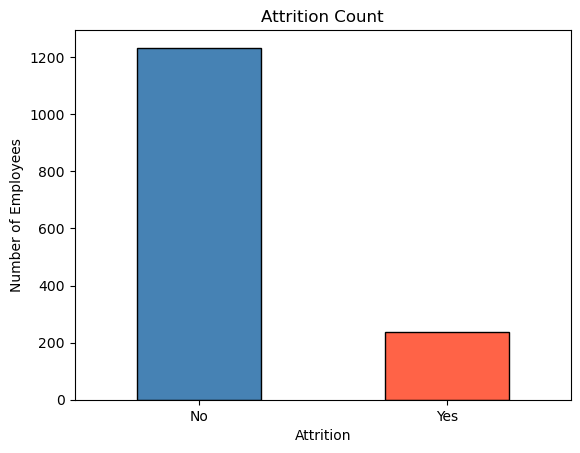

In [20]:
# Chart 1 — Attrition Count (Bar Chart)
df['Attrition'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Attrition Count')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.show()

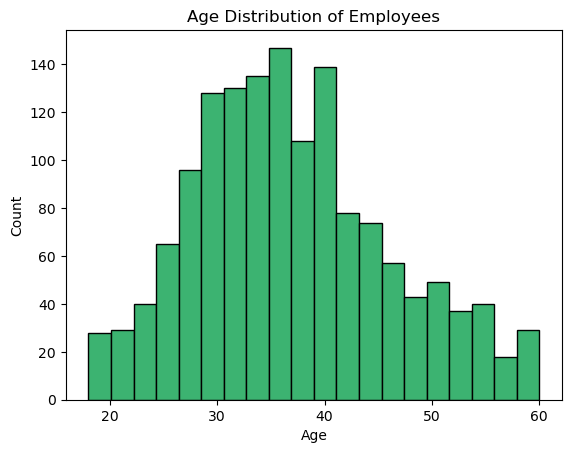

In [21]:
# Chart 2 — Age Distribution (Histogram)
plt.hist(df['Age'], bins=20, color='mediumseagreen', edgecolor='black')
plt.title('Age Distribution of Employees')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

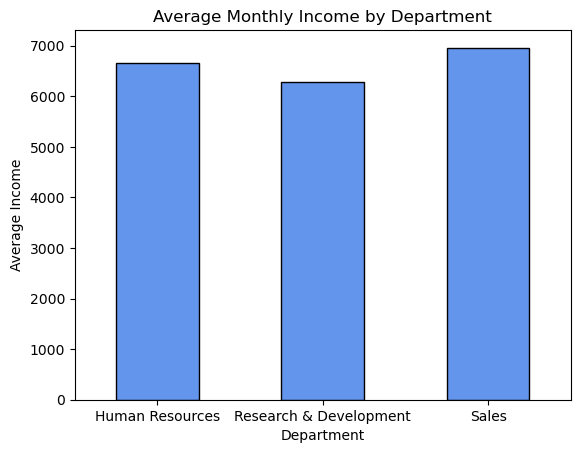

In [22]:
# Chart 3 — Average Income by Department (Bar Chart)
df.groupby('Department')['MonthlyIncome'].mean().plot(kind='bar', color='cornflowerblue', edgecolor='black')
plt.title('Average Monthly Income by Department')
plt.xlabel('Department')
plt.ylabel('Average Income')
plt.xticks(rotation=0)
plt.show()

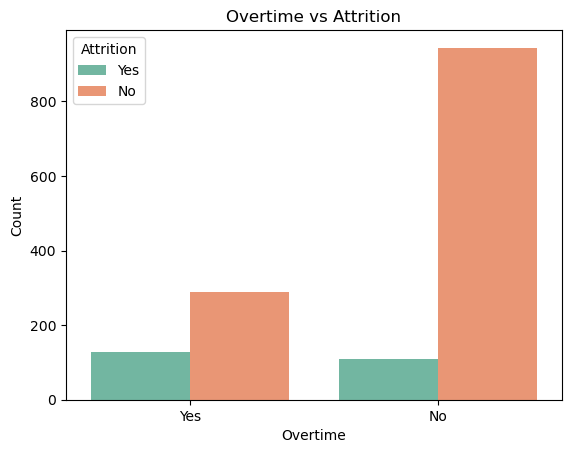

In [23]:
# Chart 4 — Overtime vs Attrition (Count Plot)
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='Set2')
plt.title('Overtime vs Attrition')
plt.xlabel('Overtime')
plt.ylabel('Count')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_18564\496165023.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='pastel')


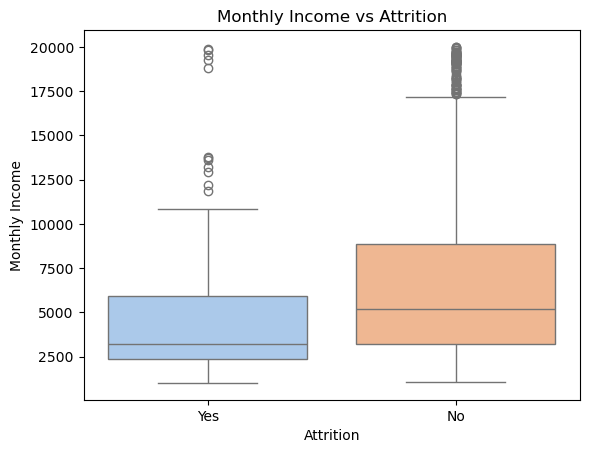

In [24]:
# Chart 5 — Income vs Attrition (Boxplot)
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='pastel')
plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.show()

## Conclusion

- 237 out of 1470 employees left the company (~16%)
- Employees doing OverTime leave more often
- Sales department has lower average monthly income
- Employees who left had lower monthly income on average
- Most employees are between 28 to 40 years old